In [1]:
library(fasthplus)
library(SpatialExperiment)
library(here)
library("sessioninfo")
library(spatialLIBD)
library(Seurat)

Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    

In [3]:
seuobj = readRDS(paste0("/data/Bin200.merge.seuobj.rds"))

In [ ]:
###read all BayesSpace outcome
meta= readRDS(paste0("/data/work/00.human.brain.atlas/06.Layer.identify.method/00.data/06.Bayes.outcome/Bin200.5slice.debatch.bayes.clu.outcome.rds"))
seuobj = AddMetaData(seuobj,meta)

In [ ]:
seuobj$Bayes7 = as.character(seuobj$Bayes7)
seuobj$Bayes12 = as.character(seuobj$Bayes12)
seuobj$Bayes13 = as.character(seuobj$Bayes13)
seuobj$Bayes14 = as.character(seuobj$Bayes14)
seuobj$Bayes15 = as.character(seuobj$Bayes15)
seuobj$Bayes16 = as.character(seuobj$Bayes16)
seuobj$Bayes17 = as.character(seuobj$Bayes17)
seuobj$Bayes18 = as.character(seuobj$Bayes18)
seuobj$Bayes19 = as.character(seuobj$Bayes19)
seuobj$Bayes20 = as.character(seuobj$Bayes20)
seuobj$Bayes21 = as.character(seuobj$Bayes21)
seuobj$Bayes22 = as.character(seuobj$Bayes22)
seuobj$Bayes23 = as.character(seuobj$Bayes23)
seuobj$Bayes24 = as.character(seuobj$Bayes24)

In [ ]:
spe <- as.SingleCellExperiment(seuobj,assay='Spatial')

In [ ]:
dim(reducedDims(spe)$HARMONY)

In [ ]:
# hpb estimate. t = pre-bootstrap sample size, D = reduced dimensions matrix, L = cluster labels, r = number of bootstrap iterations
find_t <- function(L, proportion = 0.05) {
    initial_t <- floor(length(L) * proportion)
    smallest_cluster_size <- min(table(L))
    n_labels <- length(unique(L))
    ifelse(smallest_cluster_size > (initial_t / n_labels), initial_t, smallest_cluster_size * n_labels)
}

In [ ]:
results.all =c()
for (k in c("2","7","12","13","14","15","16","17","18","19","20","21","22","23","24")){
    k =  as.numeric(k)
initial_t <- find_t(L = colData(spe)[[paste0("Bayes", k)]], proportion = 0.01)
cluster_prop <- table(colData(spe)[[paste0("Bayes", k)]]) / ncol(spe)
bad_clusters <- which(cluster_prop < 0.01 / k)
print(paste0("bad_clusters",bad_clusters))

if (length(bad_clusters) > 0) {
    message("For k: ", k, " we are dropping small clusters: ", paste(names(bad_clusters), collapse = ", "))
    spe.sub <- spe[, !colData(spe)[[paste0("Bayes", k)]] %in% as.integer(names(bad_clusters))]
    updated_t <- find_t(colData(spe.sub)[[paste0("Bayes", k)]], 0.01)
    message("initial t: ", initial_t, "; updated t: ", updated_t)
    
    set.seed(123)
    fasthplus <- hpb(D = reducedDims(spe.sub)$HARMONY, L = colData(spe.sub)[[paste0("Bayes", k)]], t = updated_t, r = 30)
    results <- data.frame(k = k, fasthplus = fasthplus)
}else{
    set.seed(123)
    fasthplus <- hpb(D = reducedDims(spe)$HARMONY, L = colData(spe)[[paste0("Bayes", k)]], t = initial_t, r = 30)
    results <- data.frame(k = k, fasthplus = fasthplus)
    }
    results.all = rbind(results,results.all)
    }

In [173]:
write.csv(results.all,"/data/fasthplus_results.csv")

In [ ]:
### segmented_inflection_point

In [4]:
library(SpatialExperiment)
library(here)
library("sessioninfo")
library(spatialLIBD)
library(segmented)

Loading required package: MASS

Warning message:
“package ‘MASS’ was built under R version 4.2.3”
Loading required package: nlme


Attaching package: ‘nlme’


The following object is masked from ‘package:IRanges’:

    collapse




In [5]:
fasthplus = read.csv("/data/fasthplus_results.csv",row.names=1)

In [6]:
fasthplus[1:3,]

,k,fasthplus
,<int>,<dbl>
1,24,0.1381478
2,23,0.1308383
3,22,0.1381739


In [7]:
f2 <- lm(fasthplus ~ k, data = fasthplus)

In [8]:
f2


Call:
lm(formula = fasthplus ~ k, data = fasthplus)

Coefficients:
(Intercept)            k  
   0.248532    -0.005637  


In [9]:
seg2 <- segmented(f2, seg.Z = ~k, npsi = 2)

In [10]:
seg2

Call: segmented.lm(obj = f2, seg.Z = ~k, npsi = 2)

Coefficients of the linear terms:
(Intercept)            k         U1.k         U2.k  
   0.364290    -0.026691     0.028560    -0.004133  

Estimated Break-Point(s):
psi1.k  psi2.k  
 8.507  16.121  

In [11]:
### plot fastplus
library(ggplot2)

Warning message:
“package ‘ggplot2’ was built under R version 4.2.3”


In [12]:
# load original results
df <- read.csv(file = "/data/fasthplus_results.csv", header = TRUE)

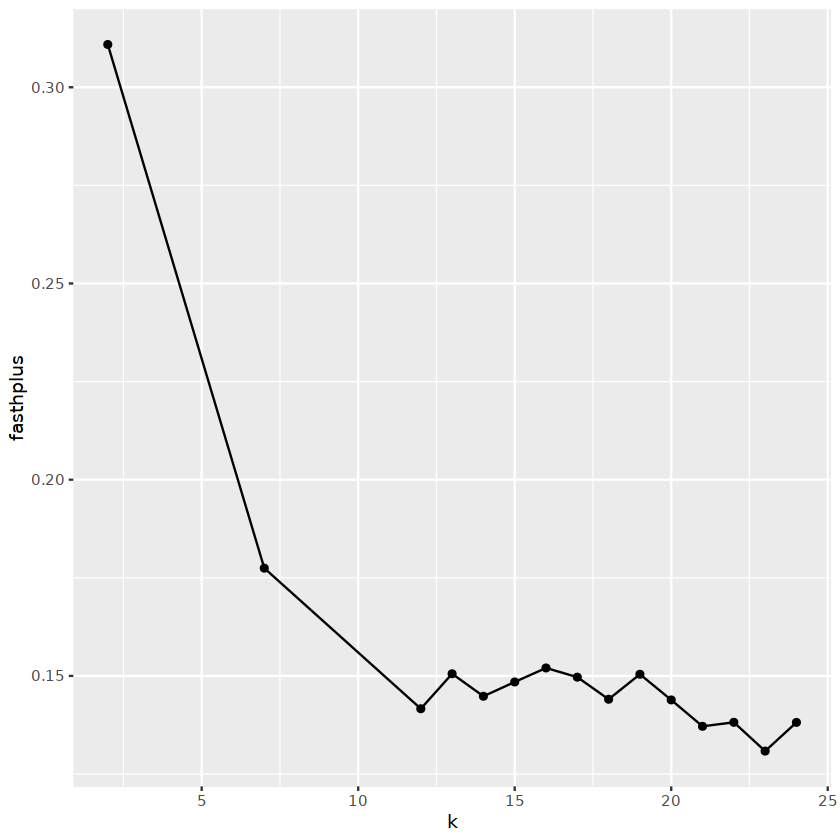

In [13]:
#pdf(file = "/dcs04/lieber/lcolladotor/spatialDLPFC_LIBD4035/spatialDLPFC/plots/06_fasthplus/fasthplus_original.pdf")
ggplot(data = df, aes(x = k, y = fasthplus, group = 1)) +
    geom_line() +
    geom_point()
#dev.off()

In [16]:
p = ggplot(data = df, aes(x = k, y = fasthplus, group = 1)) +
    geom_line() +
    geom_point() +
    ylab(expression(1 - H^{
        "+"
    })) +
    theme_bw(base_size = 20) +
    geom_vline(xintercept = 16, color = "red", size = 0.75) +
    annotate(geom = "text", label = "k = 16", x = 18.7, y = 0.14, color = "red", size = 5) +
    geom_vline(xintercept = 4, color = "gray", size = 0.75, linetype = "dotted") +
    annotate(geom = "text", label = "k = 8", x = 6.9, y = 0.16, color = "gray", size = 5)

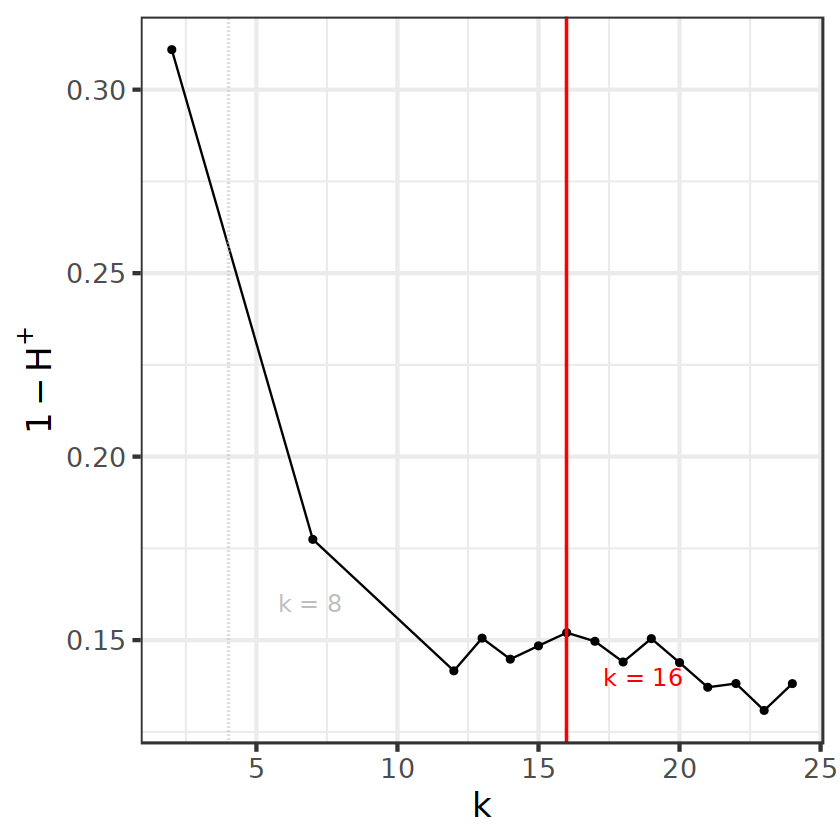

In [17]:
p

In [18]:
ggsave(plot=p,"/data/fasthplus_results.pdf")

Saving 6.67 x 6.67 in image
